In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import json
import torchvision.transforms as transforms
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from scipy.stats import linregress
from matplotlib.ticker import ScalarFormatter
from src.architectures import GeneralMLP
from src.utils import get_layer_from_checkpoint, collect_sweep_learning_curves
from src.analysis import (
    get_singular_values,
    calculate_true_mle,
    pdf_from_spectrum,
    marcenkoPastur,
    fit_marcenkoPastur,
    level_number_variance,
    GaussBroadening,
)

SWEEP_PATH = Path("mnist_mlp_sweep")
RUN_PATH = Path("mnist_mlp_sweep/alpha_1.5_g_1.0/GeneralMLP_LR0.001_BS1024_20260318_123826_s0")

# run_df = collect_run_snapshots(RUN_PATH)
curves_df = collect_sweep_learning_curves(SWEEP_PATH)
# sweep_df = collect_sweep_metrics(SWEEP_PATH)
# aggregate_displacement_sweep(SWEEP_PATH, output_name="displacement_database.parquet")
# corr_df = collect_correlations_from_json(SWEEP_PATH, method="dcor", output_name="layer_correlations_dcor.csv")

Found 9 training logs. Aggregating...
Success! Combined 5859 training steps into master log.


<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_83934/164959303.py:48: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma$ = {s_val}", fontweight="bold", fontsize=12)


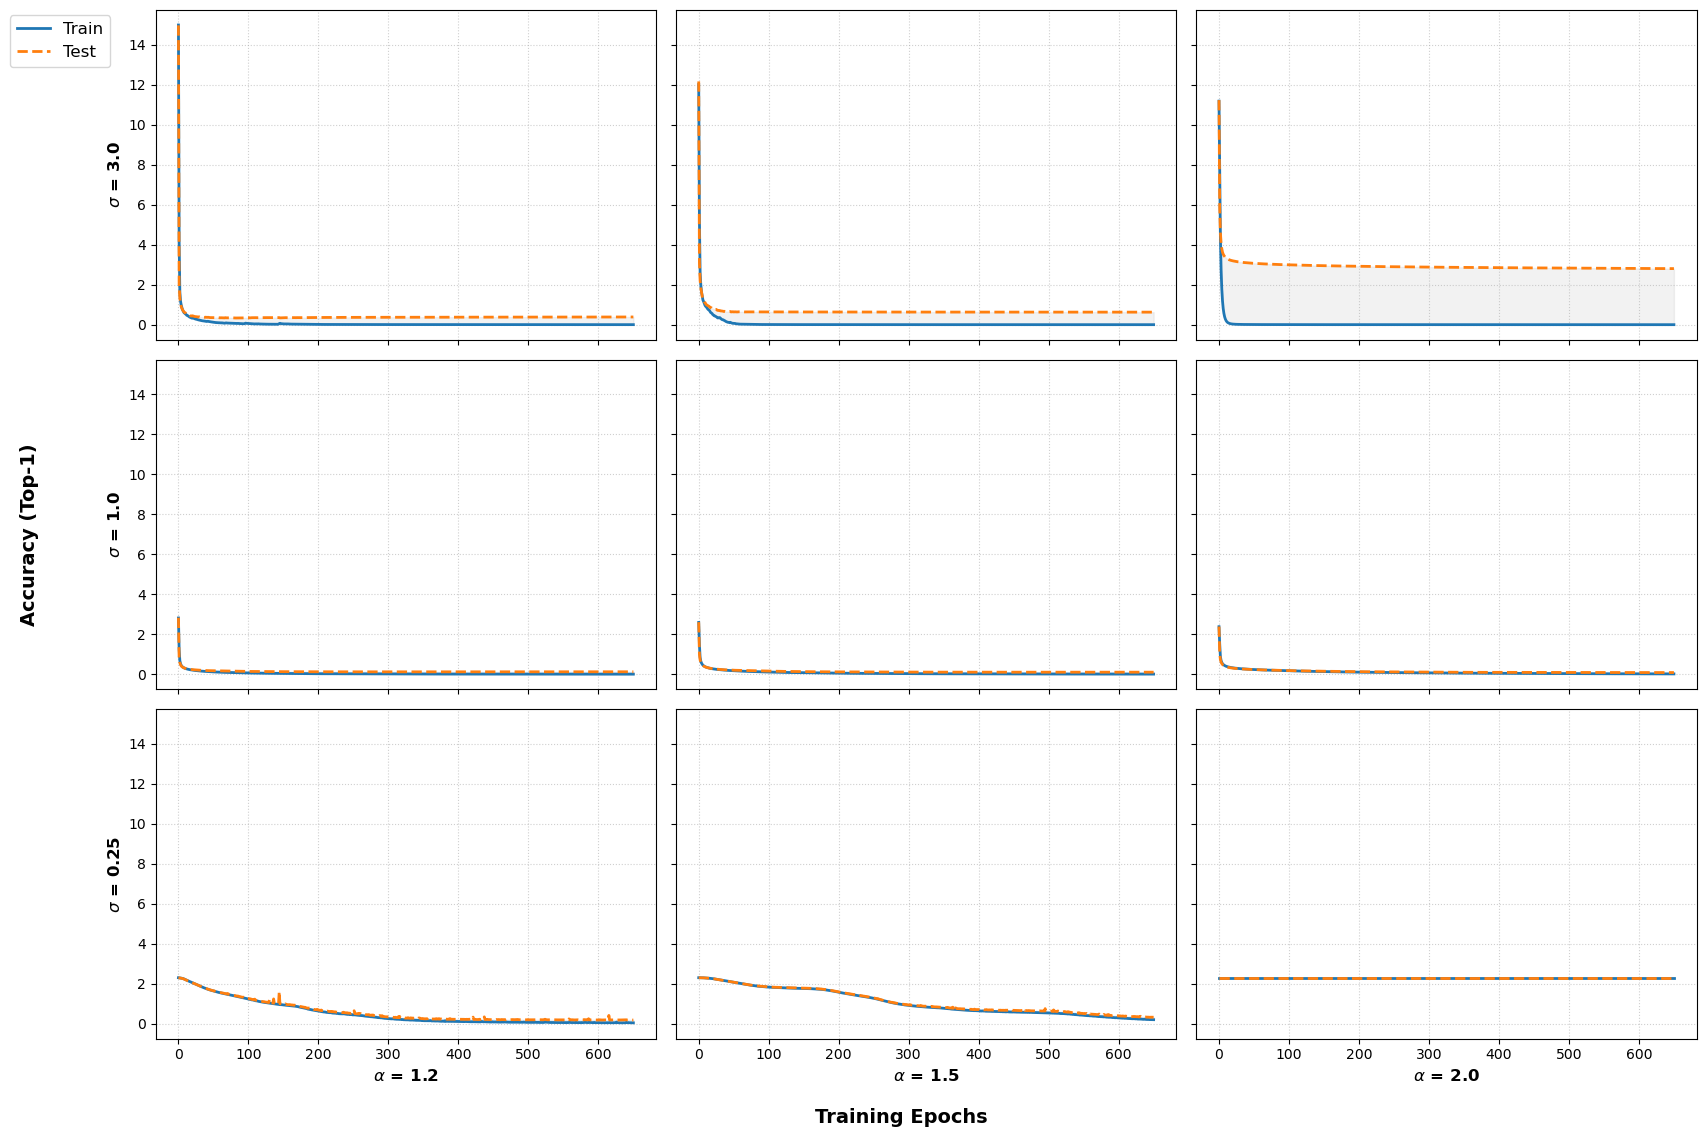

In [20]:
def plot_performance_facets(df):
    alphas = sorted(df["alpha"].unique())
    sigmas = sorted(df["sigma"].unique(), reverse=True)

    # Increase dpi for manuscript quality
    fig, axes = plt.subplots(
        len(sigmas), len(alphas), figsize=(18, 12), sharex=True, sharey=True, dpi=100
    )

    for i, s_val in enumerate(sigmas):
        for j, a_val in enumerate(alphas):
            ax = axes[i, j]
            subset = df[
                (df["alpha"] == a_val) & (df["sigma"] == s_val)
            ].sort_values("epoch")

            if not subset.empty:
                # Add a faint grid for readability
                ax.grid(True, linestyle=":", alpha=0.6)

                ax.plot(
                    subset["epoch"],
                    subset["train_loss"],
                    color="#1f77b4",
                    lw=2,
                    label="Train",
                )
                ax.plot(
                    subset["epoch"],
                    subset["test_loss"],
                    color="#ff7f0e",
                    lw=2,
                    ls="--",
                    label="Test",
                )

                # Fill the generalization gap
                ax.fill_between(
                    subset["epoch"],
                    subset["train_loss"],
                    subset["test_loss"],
                    color="gray",
                    alpha=0.1,
                )

            # Clean up labels
            if j == 0:
                ax.set_ylabel(f"$\sigma$ = {s_val}", fontweight="bold", fontsize=12)
            if i == len(sigmas) - 1:
                ax.set_xlabel(f"$\\alpha$ = {a_val}", fontweight="bold", fontsize=12)

    # Global labels
    fig.text(0.5, 0.01, "Training Epochs", ha="center", fontsize=14, fontweight="bold")
    fig.text(
        0.01,
        0.5,
        "Accuracy (Top-1)",
        va="center",
        rotation="vertical",
        fontsize=14,
        fontweight="bold",
    )

    # plt.suptitle(
    #     "Impact of Heavy-Tailed Initialization on Learning Trajectories",
    #     fontsize=20,
    #     y=0.98,
    # )

    # 1. Get handles from the first axes
    handles, labels = axes[0, 0].get_legend_handles_labels()

    # 2. Place legend on the left
    # loc="center left" keeps it vertically centered
    # bbox_to_anchor=(0.02, 0.5) places it near the left edge (x=0.02, y=0.5)
    fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.0, 0.94), fontsize=12)

    # 3. Adjust tight_layout to start further right (left=0.15) to make room
    plt.tight_layout(rect=[0.05, 0.03, 0.95, 0.95])
    plt.savefig("performance_runs.pdf", bbox_inches="tight")  # Save as PDF for high quality
    plt.show()

def print_performance_summary_table(master_df):
    """
    Groups by run, extracts the final epoch values,
    calculates the generalization gap, and prints a summary.
    """
    # 1. Identify the last epoch for every unique run
    # We group by alpha and sigma (and run_id just in case of multiple seeds)
    summary = master_df.sort_values("epoch").groupby(["init_alpha", "init_sigma", "run_id"]).tail(1).copy()

    # 2. Calculate the Generalization Gap
    # Gap = Train Accuracy - Test Accuracy
    summary["gen_gap"] = summary["train_acc"] - summary["test_acc"]

    # 3. Select and rename columns for a clean display
    display_df = summary[[
        "init_alpha",
        "init_sigma",
        "train_acc",
        "test_acc",
        "gen_gap"
    ]].copy()

    # 4. Sort by sigma (descending) then alpha (ascending) to match your 3x3 plot logic
    display_df = display_df.sort_values(["init_sigma", "init_alpha"], ascending=[False, True])

    # 5. Print with nice formatting
    print("\n" + "="*80)
    print("FINAL PERFORMANCE SUMMARY TABLE")
    print("="*80)
    # Using tabulate or just pandas string formatting
    print(display_df.to_string(index=False, justify='center', float_format=lambda x: f"{x:.4f}"))
    print("="*80)

    return display_df

# Usage:
final_stats_df = plot_performance_facets(curves_df)

<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13633/3610103566.py:85: SyntaxWarning: invalid escape sequence '\s'
  ax.set_ylabel(f"$\sigma$={s_val}", fontweight="bold", fontsize=10)


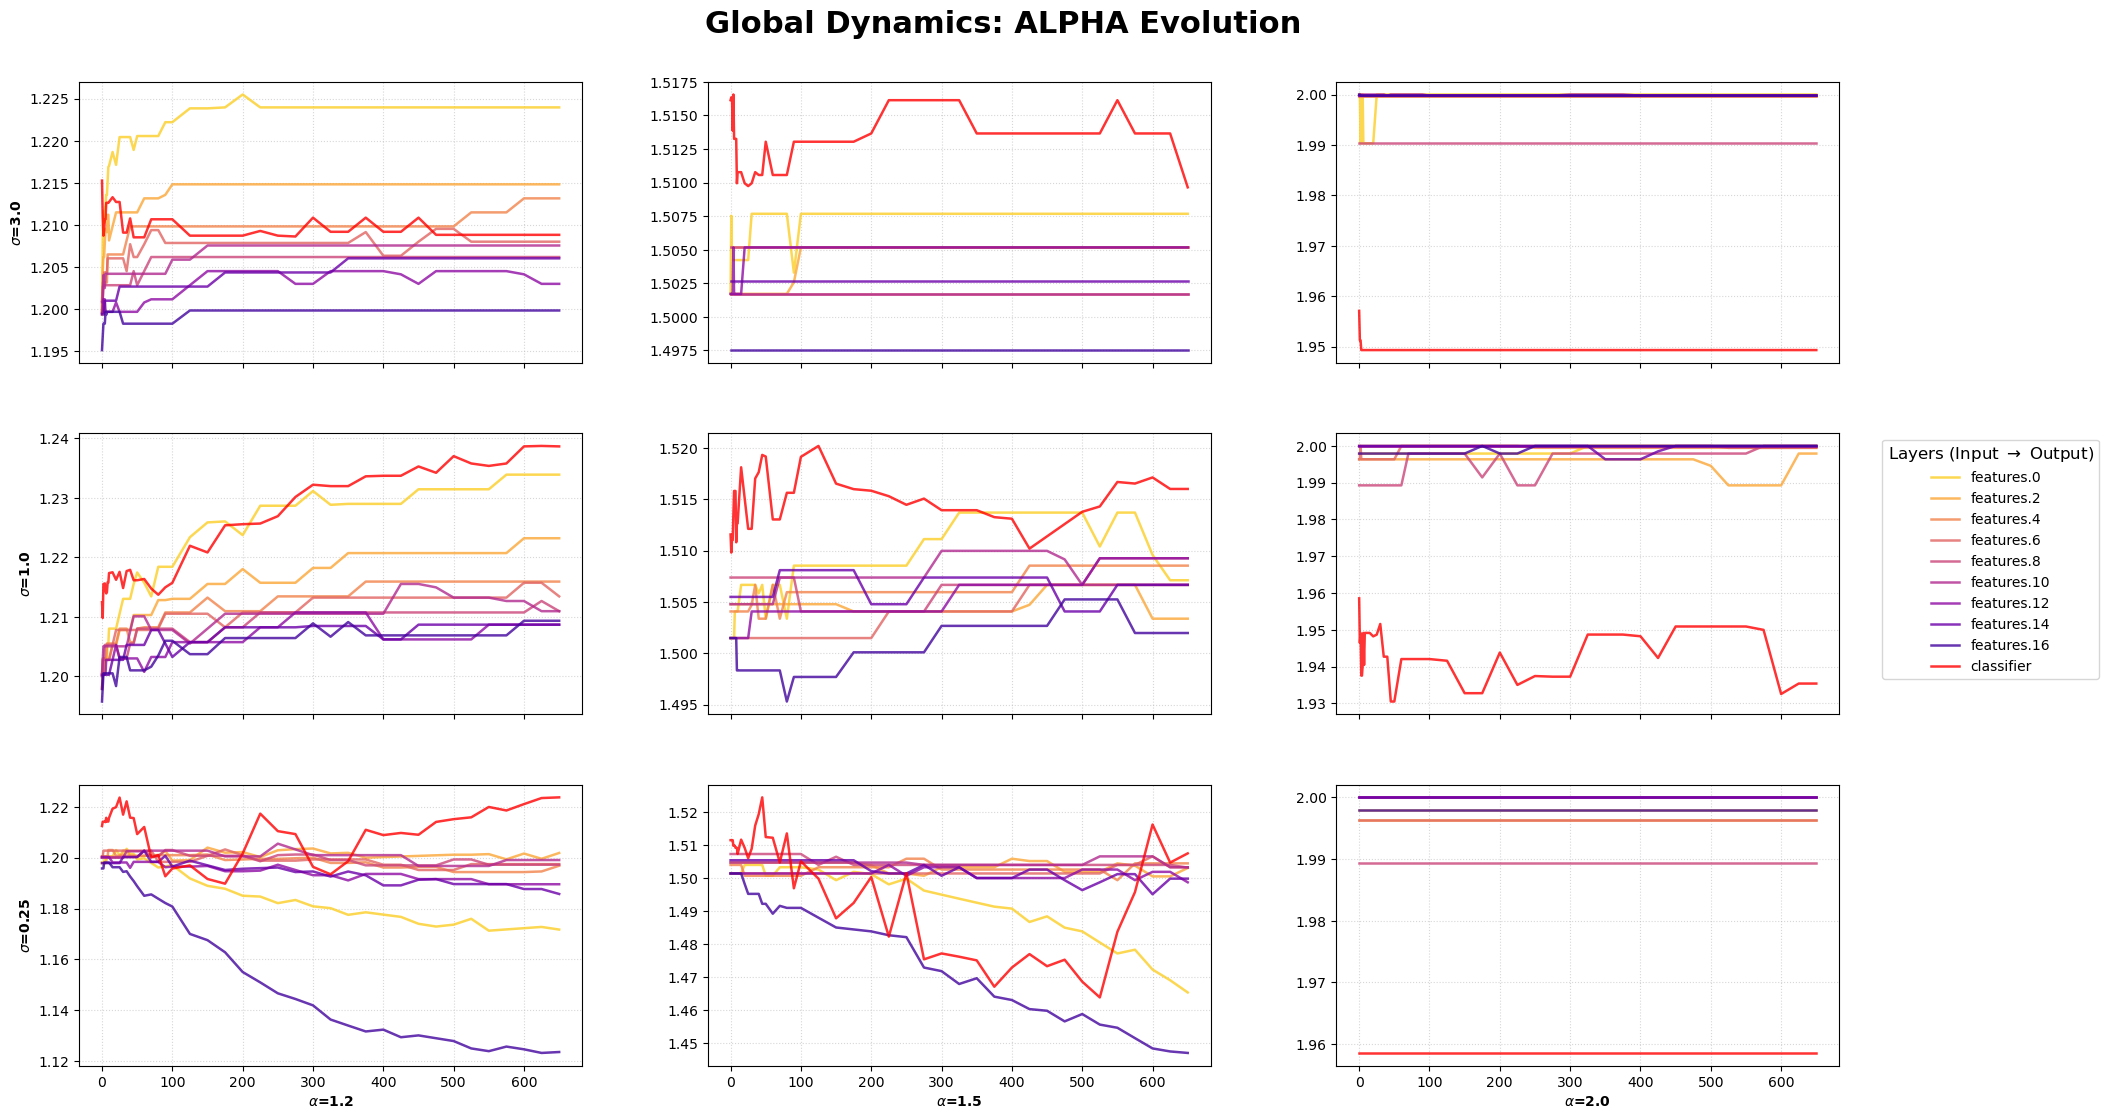

In [9]:
sweep_df = pd.read_csv("sweep_metrics.csv")

def plot_combined_sweep_grid(df, metric_col="frobenius", ignore_classifier=False, plot_ratio=False):
    # 1. Setup Grid Dimensions
    alphas = sorted(df["init_alpha"].unique())
    sigmas = sorted(df["init_sigma"].unique(), reverse=True)

    # 2. Natural Sort & Color Logic
    def extract_number(s):
        nums = re.findall(r"\d+", s)
        return int(nums[0]) if "classifier" not in s else 999

    all_layers = sorted(df["layer"].unique(), key=extract_number)

    # Separate classifier for special coloring
    hidden_layers = [l for l in all_layers if "classifier" not in l]
    classifier_layer = [l for l in all_layers if "classifier" in l]

    # Map colors: Plasma for hidden, distinct color for classifier
    hidden_colors = sns.color_palette("plasma_r", len(hidden_layers))
    layer_to_color = {l: hidden_colors[i] for i, l in enumerate(hidden_layers)}
    for l in classifier_layer:
        layer_to_color[l] = "red"  # Distinctive color for the classifier

    fig, axes = plt.subplots(
        len(sigmas), len(alphas), figsize=(22, 12), sharex=True, sharey=False
    )

    # Track lines for the legend (we only need one set from one subplot)
    legend_elements = []

    for i, s_val in enumerate(sigmas):
        for j, a_val in enumerate(alphas):
            ax = axes[i, j]

            # Filter logic
            mask = (df["init_alpha"] == a_val) & (df["init_sigma"] == s_val)
            if ignore_classifier:
                mask &= ~df["layer"].str.contains("classifier")

            run_subset = df[mask]

            if not run_subset.empty:
                if plot_ratio:
                    if plot_ratio:
                        # --- RATIO LOGIC ---
                        # Pivot to get epochs as index and layers as columns
                        pivot_df = run_subset.pivot(index="epoch", columns="layer", values=metric_col)

                        # Calculate Median of hidden layers across each epoch
                        hidden_median = pivot_df[hidden_layers].median(axis=1)
                        classifier_vals = pivot_df[classifier_layer[0]]

                        # Compute Ratio
                        ratio = classifier_vals / (hidden_median + 1e-12) # epsilon for stability

                        ax.plot(pivot_df.index, ratio, color="red", lw=2.5, label="Cls / Hidden Median")
                        ax.axhline(y=1.0, color="black", linestyle="--", alpha=0.3)
                else:
                    for layer_name in all_layers:
                        layer_data = run_subset[
                            run_subset["layer"] == layer_name
                        ].sort_values("epoch")

                        if not layer_data.empty:
                            y_vals = layer_data[metric_col].values
                            # if metric_col == "frobenius":
                            #     y_vals = y_vals / y_vals[0]

                            (line,) = ax.plot(
                                layer_data["epoch"],
                                y_vals,
                                color=layer_to_color[layer_name],
                                lw=1.8,
                                alpha=0.8,
                            )

                            # Grab handles for the legend only once
                            if i == 0 and j == 0:
                                legend_elements.append(line)

            # Labels and Aesthetics
            ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
            if j == 0:
                ax.set_ylabel(f"$\sigma$={s_val}", fontweight="bold", fontsize=10)
            if i == len(sigmas) - 1:
                ax.set_xlabel(f"$\\alpha$={a_val}", fontweight="bold", fontsize=10)

            # ref_val = 1.0 if metric_col == "frobenius" else a_val
            # ax.axhline(y=ref_val, color="black", linestyle="--", alpha=0.2)
            ax.grid(True, linestyle=":", alpha=0.5)

    # 3. Dedicated Global Legend
    # Use the labels we extracted, making them look pretty
    labels = [
        l.replace(".weight", "")
        for l in all_layers
        if not (ignore_classifier and "classifier" in l)
    ]

    fig.legend(
        legend_elements,
        labels,
        loc="center right",
        title="Layers (Input $\\rightarrow$ Output)",
        title_fontsize="12",
        fontsize="10",
        frameon=True,
    )

    # 4. Final Layout Tweak
    plt.suptitle(
        f"Global Dynamics: {metric_col.upper()} Evolution",
        fontsize=22,
        y=0.96,
        fontweight="bold",
    )

    # 'right=0.88' leaves room for the legend on the right
    fig.subplots_adjust(
        top=0.90, bottom=0.08, left=0.08, right=0.88, hspace=0.25, wspace=0.25
    )

    plt.show()


# Run it
plot_combined_sweep_grid(sweep_df, metric_col="alpha", ignore_classifier=False, plot_ratio=False)

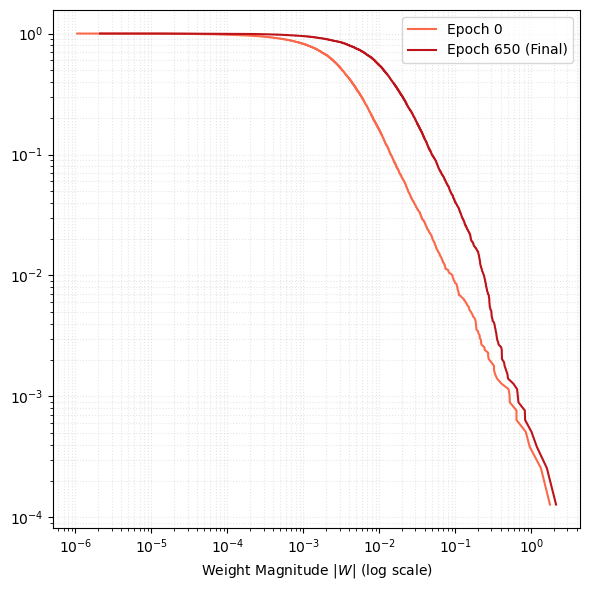

CCDF analysis complete.


In [49]:
def plot_weight_ccdf(sweep_dir, target_alpha=1.2, target_sigma = 0.25, epochs_to_plot=[0, 45], layer_name="classifier.weight"):
    """
    Loads weights from the sweep and plots the Log-Log CCDF to visualize tails.
    Uses robust path logic from the reference collection function.
    """
    sweep_path = Path(sweep_dir)
    config_files = list(sweep_path.rglob("run_config.json"))

    if not config_files:
        print(f"No run_config.json files found in {sweep_dir}")
        return

    plt.figure(figsize=(6, 6))

    for cfg_path in config_files:
        with open(cfg_path, "r") as f:
            cfg = json.load(f)

        # Only look at the run with your target init_alpha
        # HT config 'alpha' corresponds to your initialization alpha
        if cfg["ht_config"].get("alpha") != target_alpha or cfg["ht_config"].get("g") != target_sigma:
            continue

        run_dir = cfg_path.parent
        ckpt_dir = run_dir / "checkpoints"
        final_epoch = cfg["hyperparams"].get("epochs")

        # Get all available checkpoints in this run
        all_ckpts = list(ckpt_dir.glob("*.pth"))

        for i, epoch in enumerate(epochs_to_plot):
            # Logic to find the correct file for the requested epoch
            ckpt_path = None

            if epoch == -1 or epoch == final_epoch:
                target_path = ckpt_dir / "final_model.pth"
                if target_path.exists():
                    ckpt_path = target_path
            else:
                # Search for the specific epoch pattern
                pattern = f"weights_epoch_{epoch}.pth"
                target_path = ckpt_dir / pattern
                if target_path.exists():
                    ckpt_path = target_path

            if ckpt_path is None:
                print(f"Skipping: Epoch {epoch} not found in {ckpt_dir}")
                continue

            # Load weights using the reference's robust loading logic
            try:
                ckpt_data = torch.load(ckpt_path, map_location="cpu", weights_only=True)
                # Handle different state_dict saving conventions
                state_dict = ckpt_data.get("model_state", ckpt_data.get("state_dict", ckpt_data))

                colors = plt.cm.Reds(np.linspace(0.5, 0.8, len(epochs_to_plot)))
                if layer_name in state_dict:
                    # Conversion logic from reference (handle bfloat16 artifacts if needed)
                    tensor = state_dict[layer_name]
                    if "final_model" in ckpt_path.name:
                        weights = tensor.to(torch.bfloat16).to(torch.float32).numpy().flatten()
                    else:
                        weights = tensor.to(torch.float32).numpy().flatten()

                    # Statistical sorting for CCDF
                    abs_weights = np.sort(np.abs(weights))[::-1]

                    # P(|W| > x)
                    y = np.arange(1, len(abs_weights) + 1) / len(abs_weights)

                    label = f"Epoch {epoch}" if epoch != final_epoch else f"Epoch {epoch} (Final)"
                    plt.loglog(abs_weights, y, color=colors[i], label=label)

                del ckpt_data
                del state_dict

            except Exception as e:
                print(f"Error loading {ckpt_path}: {e}")

    # Formatting the plot
    # plt.title(f"Log-Log CCDF for {layer_name}\n(Initial $\\alpha={target_alpha}$)")
    plt.xlabel("Weight Magnitude $|W|$ (log scale)")
    # plt.xlim(1e-9, 1e2)  # Adjust as needed based on expected weight ranges
    # plt.ylabel("$P(|W| > x)$ (log scale)")
    # plt.ylim(1e-6, 1)  # Adjust based on expected tail probabilities
    plt.grid(True, which="both", ls=":", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"ccdf_{layer_name}_alpha_{target_alpha}_sigma_{target_sigma}.pdf", bbox_inches='tight')
    plt.show()
    print("CCDF analysis complete.")

# Usage:
plot_weight_ccdf("mnist_mlp_sweep", target_alpha=1.2, target_sigma=0.25, epochs_to_plot=[0, 650], layer_name="classifier.weight")

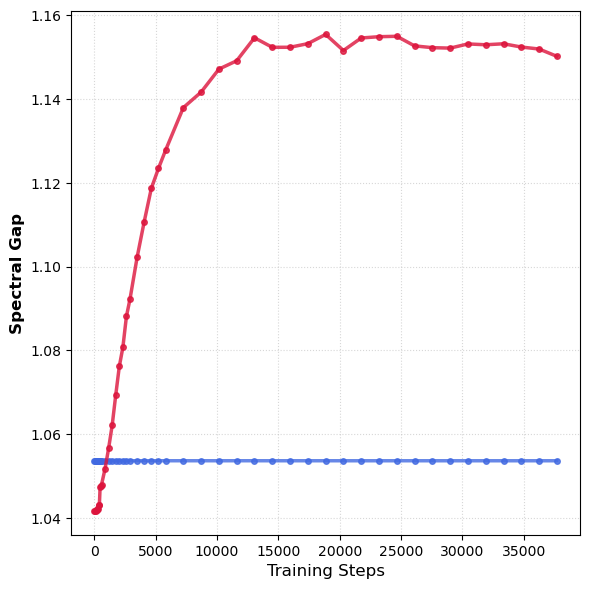

In [55]:
STEPS_PER_EPOCH = 60000 // 1024  # Assuming batch size of 1024 for MNIST

def plot_single_run_structural_evolution(csv_path, a_target=1.2, s_target=0.25, metric="stable_rank"):
    """
    Plots structural metrics (e.g., Stable Rank) for F0 and Classifier for one specific run.
    """
    df = pd.read_csv(csv_path)

    # 1. Filter for the Deep-Dive Run
    run_subset = df[(df["init_alpha"] == a_target) & (df["init_sigma"] == s_target)]

    if run_subset.empty:
        print(f"No data found for alpha={a_target}, sigma={s_target}")
        return

    # 2. Identify the Target Layers
    all_layers = run_subset["layer"].unique()
    f0_layer = [l for l in all_layers if "features.0" in l][0]
    cl_layer = [l for l in all_layers if "classifier" in l][0]

    # 3. Create Plot
    plt.figure(figsize=(6, 6))

    # Color logic to match your previous displacement plots
    colors = {f0_layer: "royalblue", cl_layer: "crimson"}
    labels = {f0_layer: "W0", cl_layer: "W10"}

    for layer in [f0_layer, cl_layer]:
        layer_data = run_subset[run_subset["layer"] == layer].sort_values("epoch")

        # Plot raw values
        plt.plot(
            layer_data["epoch"] * STEPS_PER_EPOCH,
            layer_data[metric],
            label=labels[layer],
            color=colors[layer],
            lw=2.5,
            marker='o',
            markersize=4,
            alpha=0.8
        )

    # 4. Thesis-ready Aesthetics
    # plt.title(f"Structural Evolution: {metric.replace('_', ' ').title()}\n"
    #           f"Heavy-Tailed Regime: $\\alpha$={a_target}, $\\sigma$={s_target}",
    #           fontsize=16, fontweight='bold', pad=15)

    plt.xlabel("Training Steps", fontsize=12)
    plt.ylabel(f"{metric.replace('_', ' ').title()}", fontsize=12, fontweight='bold')

    plt.grid(True, linestyle=":", alpha=0.5)
    # plt.legend(frameon=True, shadow=True)

    # Add a note about the "Transition Point" if applicable
    # Based on the paper, weights often deviate from Gaussianity around Epoch 200
    # plt.axvline(x=200, color="gray", linestyle="--", alpha=0.4, label="Predicted Gaussian Deviation")

    plt.tight_layout()
    plt.savefig(f"{metric}_{a_target}_{s_target}.pdf", bbox_inches="tight")
    plt.show()

# Run for your specific case
plot_single_run_structural_evolution("sweep_metrics.csv", a_target=1.2, s_target=0.25, metric="spectral_gap")

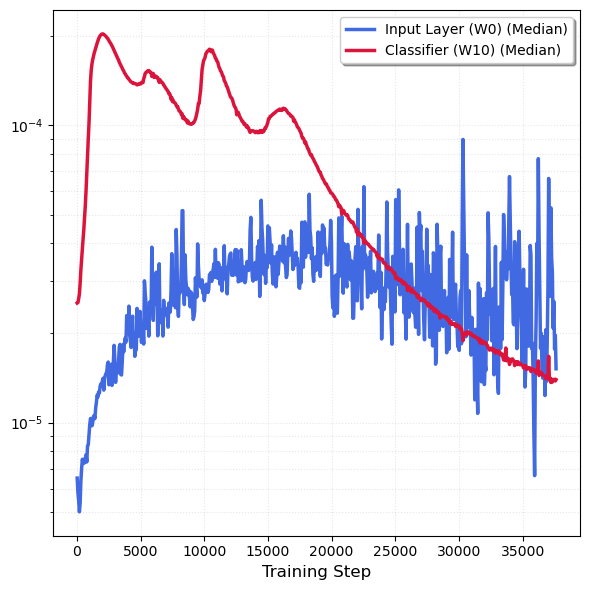

In [58]:
# 1. Setup Parameters
ALPHA_VAL = 1.2
SIGMA_VAL = 0.25
LAYER_F0 = "features.0.weight"
LAYER_CL = "classifier.weight"
LAG = 58
WINDOW_SIZE = 1  # Recommended to smooth the 'stochastic jitter'

# Load DataFrame
msd_df = pd.read_parquet("displacement_database.parquet")

def get_rolling_stats(df, layer_name, window):
    subset = df.query("alpha == @ALPHA_VAL and sigma == @SIGMA_VAL and layer == @layer_name and time_lag == @LAG").copy()
    subset = subset.sort_values("step")

    # Calculate Rolling Statistics
    subset["median"] = subset["l2_dist"].rolling(window=window, center=True).median()
    subset["q25"] = subset["l2_dist"].rolling(window=window, center=True).quantile(0.25)
    subset["q75"] = subset["l2_dist"].rolling(window=window, center=True).quantile(0.75)
    return subset

# Prepare both layers
df_f0 = get_rolling_stats(msd_df, LAYER_F0, WINDOW_SIZE)
df_cl = get_rolling_stats(msd_df, LAYER_CL, WINDOW_SIZE)

# 3. Create the Comparison Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Helper to plot layer dynamics
def plot_layer(ax, df, color, label):
    # Shaded Noise Envelope
    # ax.fill_between(df["step"], df["q25"], df["q75"], color=color, alpha=0.2)
    # Median Trend Line
    ax.plot(df["step"], df["median"], color=color, lw=2.5, label=f"{label} (Median)")
    # Optional: Very light raw data
    ax.plot(df["step"], df["l2_dist"], color=color, alpha=0.2, lw=0.5)

# Plotting
plot_layer(ax, df_f0, color='royalblue', label="Input Layer (W0)")
plot_layer(ax, df_cl, color='crimson', label="Classifier (W10)")

# Formatting for Manuscript
ax.set_yscale('log')
ax.set_xlabel('Training Step', fontsize=12)
# ax.set_ylabel(f'L2 Displacement ($\\tau$={LAG})', fontsize=12, fontweight='bold')
# ax.set_title(f"Dynamical Decoupling: Initial vs. Final Layer\n$\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL} | Heavy-Tailed Regime",
#              fontsize=16, fontweight='bold', pad=20)

ax.grid(True, which="both", ls=":", alpha=0.3)
ax.legend(loc='upper right', frameon=True, shadow=True)

fig.tight_layout()
plt.savefig("layer_dynamics_slow.pdf", bbox_inches="tight")
plt.show()

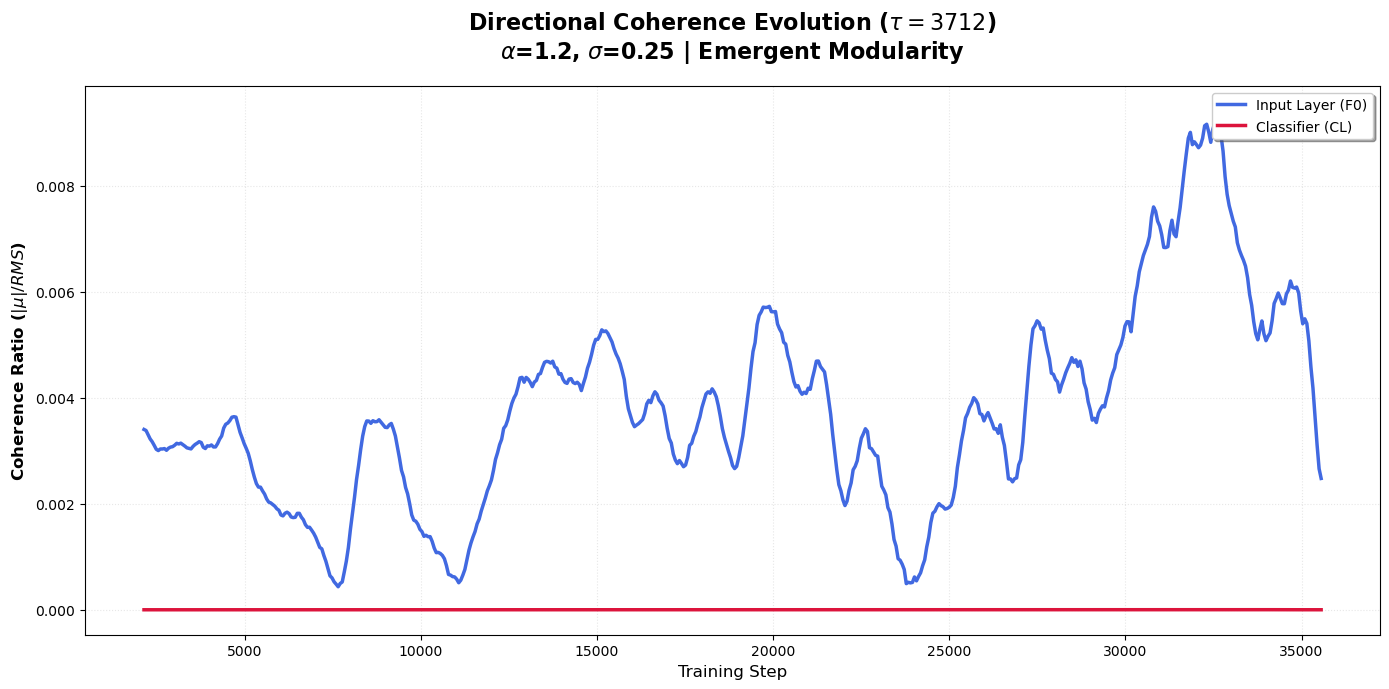

In [11]:
# 1. Setup Parameters
ALPHA_VAL = 1.2
SIGMA_VAL = 0.25
STEPS_PER_EPOCH = 60000 // 1024
LAG_TO_PLOT = 58 * 64

# Explicitly defining the layers of interest for your "Two-Island" narrative
TARGET_LAYERS = ["features.0.weight", "classifier.weight"]
LAYER_LABELS = {"features.0.weight": "Input Layer (F0)", "classifier.weight": "Classifier (CL)"}

# Load DataFrame
msd_df = pd.read_parquet("displacement_database.parquet")

# 2. Filter for the specific Alpha/Sigma run and selected layers
msd_filtered = msd_df.query(
    "alpha == @ALPHA_VAL and sigma == @SIGMA_VAL and time_lag == @LAG_TO_PLOT and layer in @TARGET_LAYERS"
)

# 3. Create the Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

# Define colors for the two distinct islands
colors = {'features.0.weight': 'royalblue', 'classifier.weight': 'crimson'}

for layer in TARGET_LAYERS:
    layer_data = msd_filtered[msd_filtered["layer"] == layer].sort_values("step")

    # Calculate the Ratio: |Net Drift| / L2 Displacement
    # This measures 'Straightness' or 'Efficiency' of the weight movement
    coherence = layer_data["net_drift"].abs() / layer_data["l2_dist"]

    # Applying a rolling mean to highlight the 'Dynamical Horizon' shift
    # window=15 is a good balance for seeing the early search vs late stability
    coherence_smoothed = coherence.rolling(window=10, center=True).mean()

    ax1.plot(layer_data["step"], coherence_smoothed,
             label=f"{LAYER_LABELS[layer]}",
             color=colors[layer], lw=2.5)

# Formatting for Manuscript
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Coherence Ratio ($|\\mu| / RMS$)', fontsize=12, fontweight='bold')
# ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y')

# Adding reference lines for physical interpretation
# ax1.axhline(0.5, ls='--', color='gray', alpha=0.5, label="High Coherence Threshold")

# Final Polish
plt.title(f"Directional Coherence Evolution ($\\tau={LAG_TO_PLOT}$)\n$\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL} | Emergent Modularity",
          fontsize=16, fontweight='bold', pad=20)

ax1.grid(True, which="both", ls=":", alpha=0.3)
ax1.legend(loc='upper right', frameon=True, shadow=True)
fig.tight_layout()

# plt.savefig("directional_coherence_comparison.pdf", bbox_inches="tight")
plt.show()

Layer W0: Gamma = 0.968 ± 0.085 (R²=0.976)
Layer W10: Gamma = 1.974 ± 0.014 (R²=1.000)


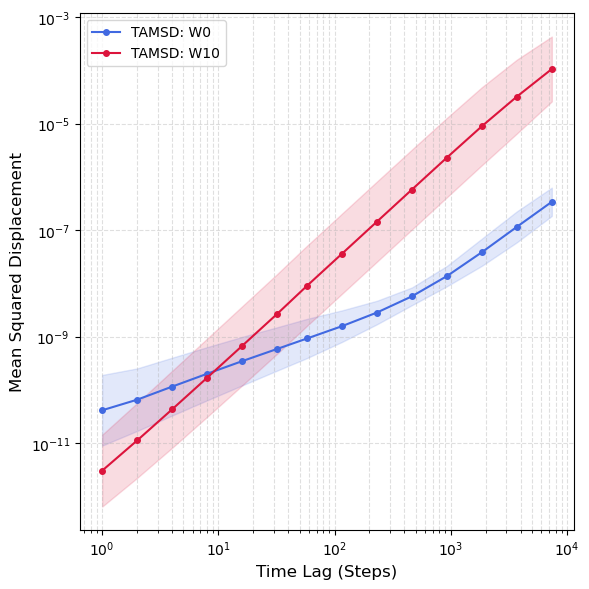

In [59]:
def calculate_tamsd(df, layer_name, alpha_val=1.2, sigma_val=0.25):
    subset = df.query("alpha == @alpha_val and sigma == @sigma_val and layer == @layer_name")

    def get_stats(x):
        squared_x = np.square(x)
        # Avoid log(0) issues
        log_squared_x = np.log(squared_x[squared_x > 0])
        return pd.Series({
            'msd': np.mean(squared_x),
            'log_std': np.std(log_squared_x) if len(log_squared_x) > 0 else 0,
            'count': len(x)
        })

    stats = subset.groupby("time_lag")["l2_dist"].apply(get_stats).unstack().reset_index()
    stats.columns = ["lag", "msd", "log_std", "count"]
    return stats

def plot_tamsd_comparison(parquet_path, layers_to_compare):
    df = pd.read_parquet(parquet_path)
    plt.figure(figsize=(6, 6))

    for layer in layers_to_compare:
        res = calculate_tamsd(df, layer)

        # Determine color/label
        is_w0 = layer == "features.0.weight"
        color = 'royalblue' if is_w0 else 'crimson'
        label_base = "W0" if is_w0 else "W10"

        # Geometric Bounds: Multiply/Divide by the exponent of log_std
        # This creates a "multiplicative" ribbon that looks clean on log scales
        lower_bound = res["msd"] / np.exp(res["log_std"])
        upper_bound = res["msd"] * np.exp(res["log_std"])

        plt.fill_between(res["lag"], lower_bound, upper_bound, color=color, alpha=0.15)

        # 2. Plot the Mean TAMSD line
        plt.loglog(res["lag"], res["msd"], marker='o', markersize=4,
                   color=color, label=f"TAMSD: {label_base}")

        # 3. STATISTICAL RIGOR: Linear Regression on Log-Log
        # We only fit the first 20% of the lags to avoid the noisy tail/bend artifacts
        # or fit the whole thing to see the "average" gamma.
        log_lag = np.log(res["lag"].values)
        log_msd = np.log(res["msd"].values)

        # linregress returns slope, intercept, r_value, p_value, and stderr
        slope, intercept, r_val, p_val, stderr = stats.linregress(log_lag, log_msd)

        # Calculate 95% CI for the slope (gamma)
        # t_crit is approx 1.96 for large N
        ci_gamma = 1.96 * stderr

        print(f"Layer {label_base}: Gamma = {slope:.3f} ± {ci_gamma:.3f} (R²={r_val**2:.3f})")

    # Formatting
    plt.xlabel("Time Lag (Steps)", fontsize=12)
    plt.ylabel("Mean Squared Displacement", fontsize=12)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.savefig("tamsd_comparison.pdf")
    plt.show()

# Example usage:
plot_tamsd_comparison("displacement_database.parquet", ["features.0.weight", "classifier.weight"])

Steps 0-5000: Gamma = 1.197 ± 0.127 (R²=0.966)
Steps 15000-20000: Gamma = 0.942 ± 0.081 (R²=0.977)
Steps 33000-38000: Gamma = 0.838 ± 0.037 (R²=0.994)


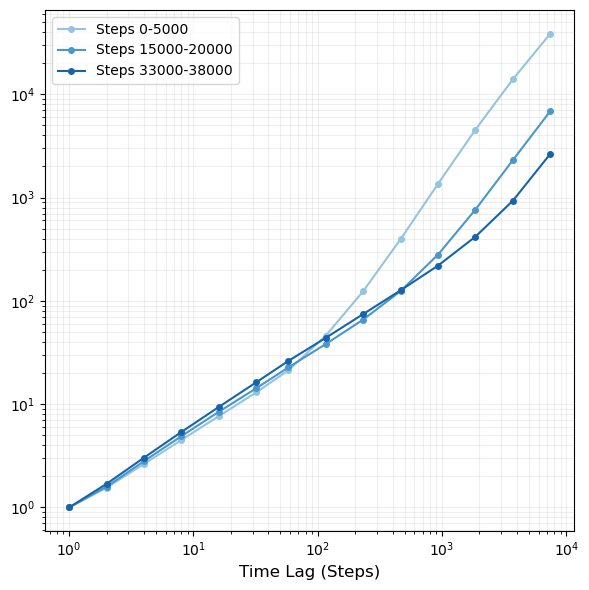

In [60]:
def calculate_tamsd_windowed(df, layer_name, window_range, alpha_val=1.2, sigma_val=0.25):
    """
    Calculates TAMSD for a specific layer within a specific training window.
    window_range: tuple (start_step, end_step)
    """
    subset = df.query("alpha == @alpha_val and sigma == @sigma_val and layer == @layer_name and step >= @window_range[0] and step < @window_range[1]")

    def get_stats(x):
        squared_x = np.square(x)
        # Avoid log(0) issues
        log_squared_x = np.log(squared_x[squared_x > 0])
        return pd.Series({
            'msd': np.mean(squared_x),
            'log_std': np.std(log_squared_x) if len(log_squared_x) > 0 else 0,
            'count': len(x)
        })

    stats = subset.groupby("time_lag")["l2_dist"].apply(get_stats).unstack().reset_index()
    stats.columns = ["lag", "msd", "log_std", "count"]
    return stats

def plot_layer_evolution_tamsd(parquet_path, layer_name, windows):
    """
    Plots the TAMSD curves for a single layer across different training stages.
    windows: list of tuples [(start, end), ...]
    """
    df = pd.read_parquet(parquet_path)
    plt.figure(figsize=(6, 6))

    # Use a colormap to show progression (e.g., from light to dark)
    colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(windows)))

    for i, window in enumerate(windows):
        res = calculate_tamsd_windowed(df, layer_name, window)

        if res is not None:
            label = f"Steps {window[0]}-{window[1]}"
            # Geometric Bounds: Multiply/Divide by the exponent of log_std
            # This creates a "multiplicative" ribbon that looks clean on log scales
            # 1. Get the normalization constant (MSD at the first lag)
            # Assuming your 'res' dataframe is sorted by lag
            msd_tau_1 = res["msd"].iloc[0]

            # Create normalized versions for plotting
            norm_msd = res["msd"] / msd_tau_1

            # 3. Plot the Normalized Mean TAMSD line
            # Now every line will strictly start at (1, 1) on the log-log plot
            plt.loglog(res["lag"], norm_msd, marker='o', markersize=4,
                    color=colors[i], label=label)

            # 4. STATISTICAL RIGOR (on normalized log values)
            log_lag = np.log(res["lag"].values)
            log_norm_msd = np.log(norm_msd.values)

            slope, intercept, r_val, p_val, stderr = stats.linregress(log_lag, log_norm_msd)

            # The slope (gamma) will be IDENTICAL to the non-normalized version,
            # but the intercept will now be 0 (since log(1) = 0).
            ci_gamma = 1.96 * stderr
            print(f"{label}: Gamma = {slope:.3f} ± {ci_gamma:.3f} (R²={r_val**2:.3f})")

    # plt.title(f"Evolution of Diffusion Horizon: {layer_name}", fontsize=15, fontweight='bold')
    plt.xlabel("Time Lag (Steps)", fontsize=12)
    # plt.ylabel("Mean Squared Displacement (TAMSD)", fontsize=12)
    plt.legend()
    plt.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    plt.savefig(f"tamsd_evolution_{layer_name}.pdf")
    plt.show()

# Example usage for your Honours Analysis:
# Define windows that represent early, middle, and late training
training_windows = [
    (0, 5000),      # Early exploration
    (15000, 20000),  # Mid-training
    (33000, 38000)   # Late convergence
]

plot_layer_evolution_tamsd("displacement_database.parquet", "features.0.weight", training_windows)

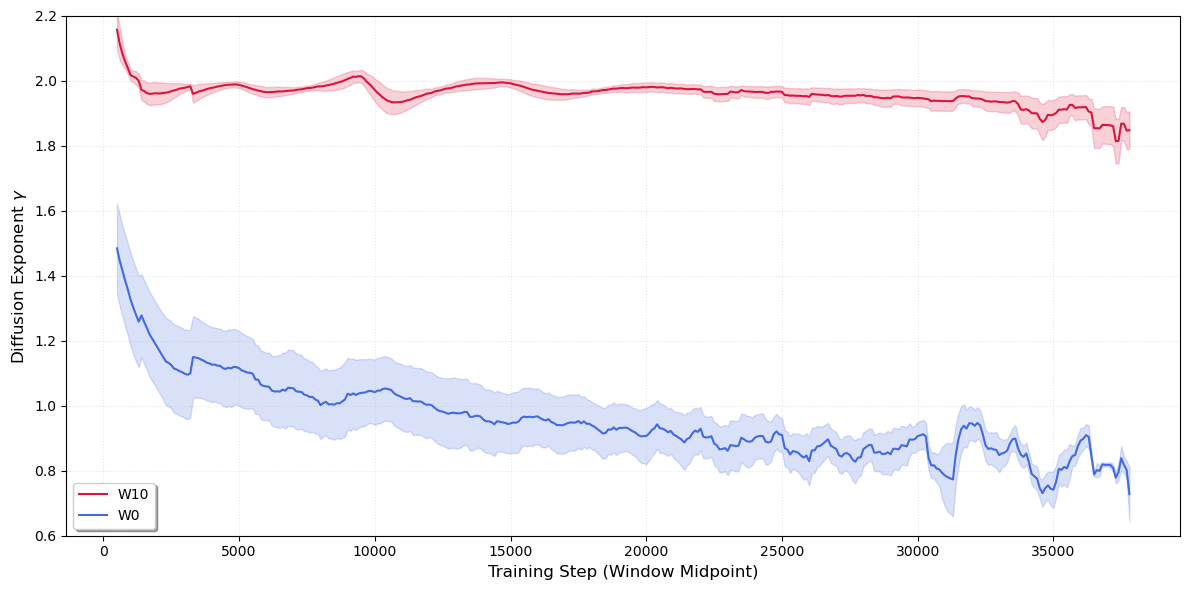

In [11]:
def calculate_rolling_tamsd(msd_df, layer_name, alpha=1.2, sigma=0.25,
                           window_size=2000, stride=200):
    """
    Calculates the evolution of the diffusion exponent gamma over training time.
    """
    subset = msd_df[
        (msd_df['layer'] == layer_name) &
        (msd_df['alpha'] == alpha) &
        (np.isclose(msd_df['sigma'], sigma))
    ].copy()

    subset = subset.sort_values(['step', 'time_lag'])
    all_steps = sorted(subset['step'].unique())
    n_steps = len(all_steps)
    results = []

    for start_idx in range(0, n_steps - window_size, stride):
        end_idx = start_idx + window_size
        window_steps = all_steps[start_idx:end_idx]
        window_data = subset[subset['step'].isin(window_steps)]

        # Calculate MSD: Mean of squared L2 displacements
        tamsd_data = window_data.groupby('time_lag')['l2_dist'].apply(lambda x: np.mean(x**2)).reset_index()
        tamsd_data = tamsd_data[tamsd_data['l2_dist'] > 0]

        if len(tamsd_data) > 3:
            log_tau = np.log10(tamsd_data['time_lag'])
            log_msd = np.log10(tamsd_data['l2_dist'])

            # Use linregress to get stderr and r_value
            slope, intercept, r_val, p_val, stderr = linregress(log_tau, log_msd)

            midpoint_step = (window_steps[0] + window_steps[-1]) / 2

            results.append({
                'step': midpoint_step,
                'gamma': slope,
                'r2': r_val**2,
                'stderr': stderr  # This is the "Honesty Metric"
            })

    return pd.DataFrame(results)

# 1. Setup and Data Loading
msd_df = pd.read_parquet("displacement_database.parquet")
ALPHA_VAL = 1.2
SIGMA_VAL = 0.25
layer_engine = "classifier.weight"   # The Terminal Layer
layer_reservoir = "features.0.weight" # The Initial Layer

# 2. Compute Dynamics for both
rolling_engine = calculate_rolling_tamsd(msd_df, layer_engine, alpha=ALPHA_VAL, sigma=SIGMA_VAL)
rolling_reservoir = calculate_rolling_tamsd(msd_df, layer_reservoir, alpha=ALPHA_VAL, sigma=SIGMA_VAL)

# 3. Plotting
plt.figure(figsize=(12, 6))

# The Terminal Layer (Blue) + Confidence Ribbon
plt.fill_between(rolling_engine['step'],
                 rolling_engine['gamma'] - 1.96 * rolling_engine['stderr'],
                 rolling_engine['gamma'] + 1.96 * rolling_engine['stderr'],
                 color='crimson', alpha=0.2)
plt.plot(rolling_engine['step'], rolling_engine['gamma'], color='crimson', label='W10')

# The Initial Layer (Orange) + Confidence Ribbon
# NOTE: This ribbon will be MUCH wider where the "bend" is severe
plt.fill_between(rolling_reservoir['step'],
                 rolling_reservoir['gamma'] - 1.96 * rolling_reservoir['stderr'],
                 rolling_reservoir['gamma'] + 1.96 * rolling_reservoir['stderr'],
                 color='royalblue', alpha=0.2)
plt.plot(rolling_reservoir['step'], rolling_reservoir['gamma'], color='royalblue', label='W0')

# Physics Reference Lines
# plt.axhline(y=1.0, color='firebrick', linestyle='--', alpha=0.5, label='Brownian Limit ($\gamma=1$)')
# plt.axhline(y=2.0, color='forestgreen', linestyle='--', alpha=0.5, label='Ballistic Limit ($\gamma=2$)')

# Final Polish
# plt.title(f"Visualizing Spatial Decoupling\n($\\alpha$={ALPHA_VAL}, $\\sigma$={SIGMA_VAL})",
#           fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Training Step (Window Midpoint)", fontsize=12)
plt.ylabel(r"Diffusion Exponent $\gamma$", fontsize=12)
plt.ylim(0.6, 2.2)
plt.grid(True, which="both", ls=":", alpha=0.3)
plt.legend(loc='lower left', frameon=True, shadow=True)

plt.tight_layout()
plt.savefig("diffusion_curve.pdf", bbox_inches="tight")  # Save as PDF for high quality
plt.show()

Applying RMT Denoising (Q=3834.90)...


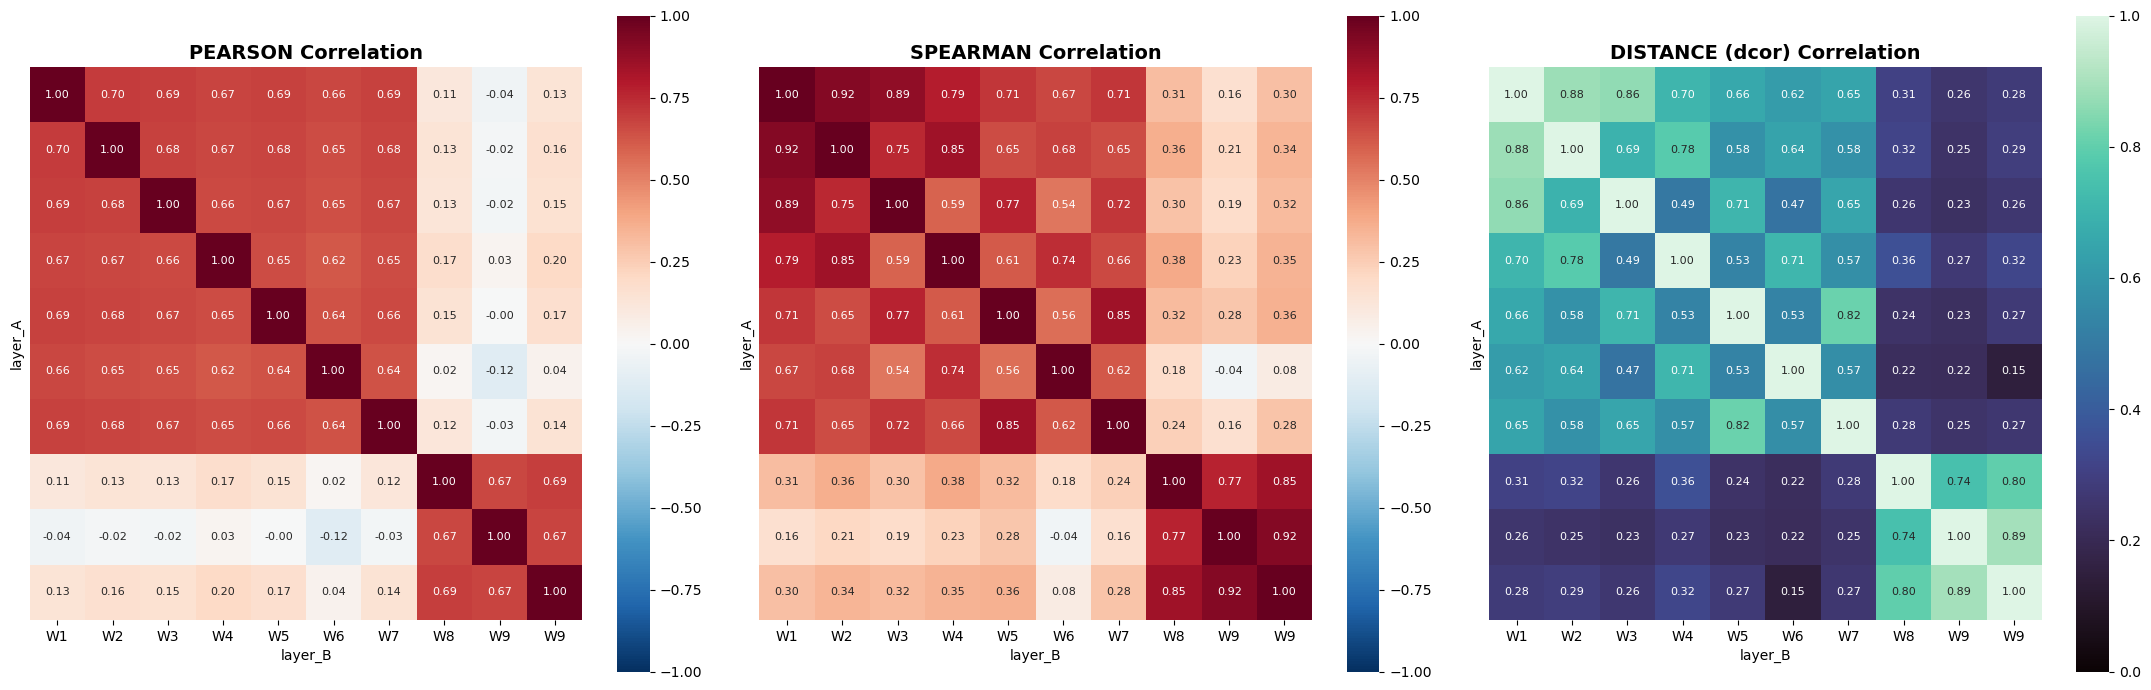

In [ ]:
import dcor
import re

def denoise_matrix(df_matrix, Q):
    """
    Applies Marchenko-Pastur Eigenvalue Clipping to a correlation matrix.
    Q = T / N (Number of observations / Number of variables)
    """
    # 1. Eigen-decomposition
    vals, vecs = np.linalg.eigh(df_matrix)

    # 2. Determine Marchenko-Pastur Upper Bound (lambda_plus)
    # sigma^2 is assumed to be 1 for a correlation matrix
    lambda_plus = (1 + np.sqrt(1/Q))**2

    # 3. Identify the "Bulk" (noise) vs "Signal"
    indices_bulk = vals <= lambda_plus
    indices_signal = vals > lambda_plus

    if not np.any(indices_bulk):
        return df_matrix # No noise found to clip

    # 4. Clipping: Replace bulk eigenvalues with their average
    # This preserves the Trace (sum of eigenvalues = N)
    avg_bulk = np.mean(vals[indices_bulk])
    vals_denoised = np.copy(vals)
    vals_denoised[indices_bulk] = avg_bulk

    # 5. Reconstruct the cleaned matrix
    cleaned_mat = vecs @ np.diag(vals_denoised) @ vecs.T

    # 6. Re-normalize to ensure diagonals are exactly 1 (it's a correlation matrix)
    d = np.diag(cleaned_mat)
    cleaned_mat = cleaned_mat / np.sqrt(np.outer(d, d))

    return pd.DataFrame(cleaned_mat, index=df_matrix.index, columns=df_matrix.columns)

def compute_and_plot_trinity(parquet_path, alpha_val, sigma_val, time_lag=1, metric_col="l2_dist", denoise=False):
    """
    Computes Pearson, Spearman, and Distance Correlation.
    If denoise=True, applies RMT cleaning to the Pearson matrix.
    """
    df_full = pd.read_parquet(parquet_path)

    subset = df_full[
        (df_full['alpha'] == alpha_val) &
        (np.isclose(df_full['sigma'], sigma_val)) &
        (df_full['time_lag'] == time_lag)
    ].copy()

    if subset.empty:
        return

    ts_matrix = subset.pivot(index="step", columns="layer", values=metric_col).dropna()
    layers = ts_matrix.columns.tolist()

    # Calculate Raw Matrices
    pearson_mat = ts_matrix.corr(method='pearson')
    spearman_mat = ts_matrix.corr(method='spearman')

    # Apply RMT Denoising if toggled
    if denoise:
        # Q = Number of steps / Number of layers
        Q_ratio = ts_matrix.shape[0] / ts_matrix.shape[1]
        print(f"Applying RMT Denoising (Q={Q_ratio:.2f})...")
        pearson_mat = denoise_matrix(pearson_mat, Q_ratio)
        # Note: We usually keep Spearman raw or apply similar logic,
        # but for Honours, denoising the primary Linear metric (Pearson) is the standard move.

    # Distance Correlation
    n_layers = len(layers)
    dcor_mat = pd.DataFrame(np.ones((n_layers, n_layers)), index=layers, columns=layers)
    for i in range(n_layers):
        for j in range(i + 1, n_layers):
            val = dcor.distance_correlation(ts_matrix.iloc[:, i], ts_matrix.iloc[:, j])
            dcor_mat.iloc[i, j] = dcor_mat.iloc[j, i] = val

    # Melt and Plot
    def melt_matrix(mat):
        mat.index.name = "layer_A"
        return mat.reset_index().melt(id_vars="layer_A", var_name="layer_B", value_name="correlation")

    df_p = melt_matrix(pearson_mat)
    df_s = melt_matrix(spearman_mat)
    df_d = melt_matrix(dcor_mat)

    plot_correlation_trinity(df_p, df_s, df_d, alpha_val, sigma_val, delta_t=time_lag)

def plot_correlation_trinity(pearson_df, spearman_df, dcor_df, alpha_val, sigma_val, delta_t=1):
    """
    Your original plotting function with minor tweaks to handle the DataFrame format.
    """
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

    methods = [
        ("PEARSON", pearson_df, "RdBu_r", (-1, 1)),
        ("SPEARMAN", spearman_df, "RdBu_r", (-1, 1)),
        ("DISTANCE (dcor)", dcor_df, "mako", (0, 1))
    ]

    def sort_key(name):
        # Sorts features.0, features.16, classifier...
        nums = re.findall(r'\d+', name)
        if 'classifier' in name.lower(): return 999
        return int(nums[0]) if nums else 0

    for i, (name, df, cmap, (vmin, vmax)) in enumerate(methods):
        ax = axes[i]

        # Standardize matrix for heatmap
        matrix = df.pivot(index="layer_A", columns="layer_B", values="correlation")
        ordered = sorted(matrix.index.tolist(), key=sort_key)
        matrix = matrix.reindex(index=ordered, columns=ordered)

        short_labels = [
            f"W{(int(re.findall(r'\d+', l)[0]) // 2) + 1}" if 'features' in l else f"W{len(ordered)-1}"
            for l in ordered
        ]

        sns.heatmap(
            matrix, ax=ax, annot=True, fmt=".2f", annot_kws={"size": 8},
            cmap=cmap, vmin=vmin, vmax=vmax, square=True, cbar=True,
            xticklabels=short_labels,
            yticklabels=short_labels if i == 0 else False
        )

        ax.set_title(f"{name} Correlation", fontsize=14, fontweight='bold')

    # plt.suptitle(f"Metric Comparison | $\\alpha$={alpha_val}, $\\sigma$={sigma_val} | Lag={delta_t}",
    #              fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig("correlations.pdf", bbox_inches="tight")  # Save as PDF for high quality
    plt.show()

# EXECUTION:
compute_and_plot_trinity("displacement_database.parquet", alpha_val=1.2, sigma_val=0.25, time_lag=1, denoise=True)

In [ ]:
# 1. Initialization and Data Extraction

LAYER_KEY = 'features.2.weight'
W_final = get_layer_from_checkpoint(RUN_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(RUN_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)

nu_final = get_singular_values(W_final)
nu_init  = get_singular_values(W_init)

# Use the official adaptive Broadener from source code

broadener = GaussBroadening(winSize=15, method='replicate')

fig, ax = plt.subplots(figsize=(9, 6))

# Determine global x-limit based on the maximum singular value found in training

x_limit = np.max(nu_final) * 1.2

data_configs = [
(nu_init, 'Initialization (Epoch 0)', 'red'),
(nu_final, 'Fully Trained', '#1d3557') # Dark blue matching paper Fig 1
]

for nu, label, color in data_configs:
    # A. EMPIRICAL DENSITY (Solid Line)
    # Generate high-resolution x and pdf using the official iterative sampler
    x_emp, pdf_emp = pdf_from_spectrum(nu, nSamples=20, broadener=broadener)

    # Mask to ensure it only plots within the viewport
    mask = (x_emp >= 0) & (x_emp <= x_limit)
    ax.plot(x_emp[mask], pdf_emp[mask], color=color, lw=2, label=label, zorder=4)

    # B. RMT THEORY FIT (Dashed Line)
    # [cite_start]This uses the authors' logic to fit ONLY the random bulk [cite: 2427, 2429]
    # range_of_y_to_fit=0.7 prevents the tail from stretching the bulk fit
    a_fit, nuMin_fit, nuMax_fit, _ = fit_marcenkoPastur(nu, broadener, range_of_y_to_fit=0.7)

    # [cite_start]Evaluate theory curve within its specific theoretical support [cite: 2381, 2386]
    x_bulk = np.linspace(nuMin_fit, nuMax_fit, 400)
    y_bulk = marcenkoPastur(x_bulk, a_fit, nuMax_fit, nuMin_fit)

    ax.plot(x_bulk, y_bulk, color='black', linestyle='--', lw=1.2, zorder=5)

    # 2. Physical Review E Aesthetics (Matching Figure 1)

    ax.set_yscale('linear')
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, x_limit)

    ax.set_xlabel(r'singular value $\nu$', fontsize=13)
    ax.set_ylabel('probability density', fontsize=13)

# Professional scientific formatting

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='in', top=True, right=True, which='both')
ax.legend(frameon=False, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def plot_dual_level_variance(w_init, w_final, win_size=15):
    """
    Recreates Fig 3: Level number variance comparing initial (red)
    and trained (blue) weights.
    """
    # 1. Extract and sort singular values (Cite: 709, 860)
    s_init = np.sort(get_singular_values(w_init))
    s_final = np.sort(get_singular_values(w_final))

    # 2. Setup Broadener and Parameters (Cite: 754, 758)
    broadener = GaussBroadening(winSize=win_size, method='replicate')
    L_range = np.linspace(0.1, 20, 200) # (Cite: 777)
    opts = {'tol': 0.01, 'maxIterations': 1000, 'minIterations': 100}

    # 3. Compute empirical variance for both (Cite: 774, 775)
    _, sigma_init = level_number_variance(s_init, broadener, L_range, **opts)
    _, sigma_final = level_number_variance(s_final, broadener, L_range, **opts)

    # 4. Theoretical GOE Prediction (Cite: 777, 959)
    gamma = np.euler_gamma
    sigma_goe = (2 / np.pi**2) * (np.log(2 * np.pi * L_range) + gamma + 1 - (np.pi**2 / 8))

    # 5. Visualization (Matches Fig 3/7 colors) (Cite: 810, 995)
    plt.figure(figsize=(8, 6))

    # GOE Theory - Black Dashed (Cite: 811)
    plt.plot(L_range, sigma_goe, 'k--', lw=2, label='Theory (GOE)')

    # Initial - Red (Cite: 779, 810)
    plt.plot(L_range, sigma_init, color='red', lw=1.5, alpha=0.8, label='Initial')

    # Trained - Blue (Cite: 779, 810)
    plt.plot(L_range, sigma_final, color='#1f77b4', lw=1.5, alpha=0.8, label='Trained')

    plt.xlabel('l', fontsize=14)
    plt.ylabel(r'$\Sigma^2(l)$', fontsize=14)
    plt.title(f'Level Number Variance', fontsize=14)
    plt.xlim(0, 20)
    plt.ylim(0, 2.0)
    plt.legend(frameon=False)
    plt.grid(alpha=0.2)
    plt.show()

# Example Usage:
LAYER_KEY = 'features.2.weight'
W_final = get_layer_from_checkpoint(RUN_PATH / "final_model.pth", LAYER_KEY)
W_init  = get_layer_from_checkpoint(RUN_PATH / "checkpoints/weights_epoch_0.pth", LAYER_KEY)
plot_dual_level_variance(W_init, W_final, win_size=15)

In [ ]:
def get_full_weight_chain(checkpoint_path, layer_names=None):
    """
    Loads a checkpoint and returns weights in the SPECIFIC order of the forward pass.
    """
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    state_dict = ckpt.get('model_state', ckpt)

    # If you know your layer names, list them here in order!
    # Example for a common CIFAR MLP:
    if layer_names is None:
        # Fallback: try to filter and sort, but print the order so you can verify
        keys = sorted([k for k in state_dict.keys() if 'weight' in k and 'bn' not in k.lower()],
                      key=lambda x: [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', x)])
    else:
        keys = layer_names

    # print(f"  -> Building chain from keys: {keys}")
    return [state_dict[k].float() for k in keys]

def plot_lyapunov_evolution(run_dir, activation='relu', input_dim=784,
                                     layer_names=None, num_samples=20):
    """
    Analyzes checkpoints and plots the Mean MLE with a Standard Deviation shaded region.

    Args:
        num_samples: Number of times to run the MLE per checkpoint (the 'X' times).
    """
    checkpoint_dir = Path(run_dir) / "checkpoints"
    if not checkpoint_dir.exists():
        checkpoint_dir = Path(run_dir)

    checkpoint_files = list(checkpoint_dir.glob("weights_epoch_*.pth"))
    if not checkpoint_files:
        checkpoint_files = list(checkpoint_dir.glob("*.pth"))

    def extract_epoch(f):
        nums = re.findall(r'\d+', f.name)
        return int(nums[-1]) if nums else 0

    checkpoint_files.sort(key=extract_epoch)

    epochs = []
    mle_means = []
    mle_stds = []

    # print(f"Processing {len(checkpoint_files)} checkpoints (Ensemble size: {num_samples})...")

    for f in checkpoint_files:
        # Load weights once for the checkpoint
        weights = get_full_weight_chain(f, layer_names=layer_names)
        if not weights: continue

        # Run the calculation X times to account for stochasticity
        batch_mles = []
        for _ in range(num_samples):
            # Generate a new random input sample for each iteration
            sample_input = torch.randn(1, input_dim)
            mle = calculate_true_mle(weights, sample_input, activation=activation)
            batch_mles.append(mle)

        epochs.append(extract_epoch(f))
        mle_means.append(np.mean(batch_mles))
        mle_stds.append(np.std(batch_mles))

        # print(f"  Epoch {epochs[-1]:3d} | Mean MLE: {mle_means[-1]:.4f} +/- {mle_stds[-1]:.4f}")

    # Convert to numpy arrays for plotting
    epochs = np.array(epochs)
    means = np.array(mle_means)
    stds = np.array(mle_stds)

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))

    # Plot the shaded Standard Deviation region
    plt.fill_between(epochs, means - stds, means + stds,
                     color='#e31a1c', alpha=0.2, label=f'StDev (N={num_samples})')

    # Plot the Mean line
    plt.plot(epochs, means, 'o-', color='#e31a1c', markersize=4, linewidth=2, label='Ensemble Mean MLE')

    # Criticality Reference
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Criticality ($\lambda=0$)')

    plt.title(f"Dynamical Stability Ensemble: {Path(run_dir).name}", fontsize=12)
    plt.xlabel("Training Epoch", fontsize=11)
    plt.ylabel("Maximal Lyapunov Exponent ($\lambda$)", fontsize=11)
    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- EXAMPLE USAGE ---
CIFAR_LAYERS = [
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    # 'features.6.weight',
    # 'features.8.weight',
    # 'features.10.weight',
    # 'features.12.weight',
    # 'features.14.weight',
    # 'features.16.weight',
    'classifier.weight'
]
plot_lyapunov_evolution(RUN_PATH, activation='relu', input_dim=3072, layer_names=CIFAR_LAYERS, num_samples=100)

In [ ]:
from torchvision.datasets import CIFAR10, MNIST
from torch.utils.data import DataLoader
import torch.nn as nn

def calculate_empirical_ql_flow(run_dir, alpha=1.2, device='cpu'):
    """
    Calculates the empirical scale parameter q_l across all layers and checkpoints
    strictly following the alpha-moment definition in the Qu et al. manuscript.
    """
    run_path = Path(run_dir)
    with open(run_path / "run_config.json", "r") as f:
        config = json.load(f)

    # 1. Data Setup (To get the input x0)
    data_cfg = config['data_config']
    norm_mean = data_cfg['transforms'][1]['Normalize']['mean']
    norm_std = data_cfg['transforms'][1]['Normalize']['std']

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=norm_mean, std=norm_std)
    ])

    ds_class = CIFAR10 if data_cfg['dataset_name'] == 'CIFAR10' else MNIST
    dataset = ds_class(root='./data', train=False, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=data_cfg['batch_size'], shuffle=True)

    # Get initial input x0
    x, _ = next(iter(loader))
    x = x.to(device).view(x.size(0), -1)

    # 2. Model Reconstruction
    model_params = config['model_params']['kwargs']
    # Extract Dw/Db if parameterized in your init, else we treat the weights as-is
    model = GeneralMLP(**model_params).to(device)
    activation_fn = nn.ReLU() if model_params['activation_name'] == 'relu' else nn.Tanh()

    checkpoint_dir = run_path / "checkpoints"
    ckpt_files = sorted(list(checkpoint_dir.glob("weights_epoch_*.pth")),
                        key=lambda x: int(x.stem.split('_')[-1]))

    results = {} # Epoch -> List of q_l values

    for ckpt_p in ckpt_files:
        epoch = int(ckpt_p.stem.split('_')[-1])
        state = torch.load(ckpt_p, map_location=device)
        model.load_state_dict(state.get('model_state', state))
        model.eval()

        # q0: The starting energy of the input data
        # Equation: q0 = (1/N) * sum(|x0|^alpha)
        q_flow = [torch.mean(torch.abs(x)**alpha).item()]

        curr_act = x
        with torch.no_grad():
            # Propagate through the 'features' Sequential block
            for layer in model.features:
                if isinstance(layer, nn.Linear):
                    # Linear transformation: h = Wx + b
                    h = layer(curr_act)
                    # Non-linear activation: x_next = phi(h)
                    curr_act = activation_fn(h)

                    # Calculate empirical q_l for this layer
                    # Strictly: q_l = mean(|phi(h)|^alpha)
                    q_l = torch.mean(torch.abs(curr_act)**alpha).item()
                    q_flow.append(q_l)

            # Final Classifier Layer
            h_final = model.classifier(curr_act)
            # The paper usually stops at the last hidden layer, but we include it for completeness
            q_final = torch.mean(torch.abs(h_final)**alpha).item()
            q_flow.append(q_final)

        results[epoch] = q_flow
        print(f"Epoch {epoch} | q_start: {q_flow[0]:.4f} | q_end: {q_flow[-1]:.4f}")

    return results

# --- 4. PLOTTING THE "ENERGY FLOW" ---

def plot_energy_flow(results, layer_names):
    plt.figure(figsize=(10, 6))

    # Plot first, middle, and last epoch to see the evolution
    epochs_to_show = [min(results.keys()), max(results.keys()) // 2, max(results.keys())]

    for epoch in epochs_to_show:
        if epoch in results:
            plt.plot(range(len(layer_names)), results[epoch], 'o-', label=f'Epoch {epoch}')

    plt.xticks(range(len(layer_names)), layer_names, rotation=45)
    plt.yscale('log') # Scale parameters often vary by orders of magnitude
    plt.ylabel("Scale Parameter $q_l$ (Log Scale)")
    plt.xlabel("Layer")
    plt.title("Lévy Mean Field: Energy Flow Across Layers")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

LAYERS = [
    'INPUT',
    'features.0.weight',
    'features.2.weight',
    'features.4.weight',
    # 'features.6.weight',
    # 'features.8.weight',
    # 'features.10.weight',
    # 'features.12.weight',
    # 'features.14.weight',
    # 'features.16.weight',
    'classifier.weight'
]
results = calculate_empirical_ql_flow(RUN_PATH, alpha=1.2, device='cuda')
plot_energy_flow(results, LAYERS)